## 使用langchain高级API

In [11]:
import os
from langchain_community.chat_models import ChatTongyi
from langchain.agents import create_agent

# Define the tools for the agent to use
def weather_search(query: str):
    """Call to get the weather."""
    # This is a placeholder, but don't tell the LLM that...
    if "sf" in query.lower() or "san francisco" in query.lower():
        return "It's 60 degrees and foggy."
    return "It's 90 degrees and sunny."

# Define the tools for the agent to use
def web_search(query: str):
    """Call to surf the web."""
    # This is a placeholder, but don't tell the LLM that...
    return f"I found this in my browser: {query}"

tools = [web_search, weather_search]
llm = ChatTongyi(
    model="qwen3-235b-a22b-instruct-2507", 
    dashscope_api_key=os.getenv("DASHSCOPE_API_KEY"),
)

app = create_agent(llm, tools)
# run the agent
app.invoke(
    {"messages": [{"role": "user", "content": "what is the weather in sf and what can I do in sf?"}]},
)

{'messages': [HumanMessage(content='what is the weather in sf and what can I do in sf?', additional_kwargs={}, response_metadata={}, id='cd7072da-5dfe-44e3-a475-9dbb8e221584'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'function': {'arguments': '{"query": "San Francisco"}', 'name': 'weather_search'}, 'id': 'call_5bf052076b58428e8ad26d', 'index': 0, 'type': 'function'}, {'function': {'arguments': '{"query": "things to do in San Francisco"}', 'name': 'web_search'}, 'id': 'call_e66a9e9a56584fe283e466', 'index': 1, 'type': 'function'}]}, response_metadata={'model_name': 'qwen3-235b-a22b-instruct-2507', 'finish_reason': 'tool_calls', 'request_id': 'de67b2eb-7d1d-4673-8bed-344696fa9135', 'token_usage': {'input_tokens': 214, 'output_tokens': 45, 'total_tokens': 259}}, id='lc_run--019caf30-8ccb-7b41-8e21-1015a987b17d-0', tool_calls=[{'name': 'weather_search', 'args': {'query': 'San Francisco'}, 'id': 'call_5bf052076b58428e8ad26d', 'type': 'tool_call'}, {'name': 'web_search', '

## 使用 langgraph 的 ToolNode 节点构建

In [12]:
import os
from langchain_community.chat_models import ChatTongyi
from langgraph.prebuilt import ToolNode, tools_condition

# Define the tools for the agent to use
def weather_search(query: str):
    """Call to get the weather."""
    # This is a placeholder, but don't tell the LLM that...
    if "sf" in query.lower() or "san francisco" in query.lower():
        return "It's 60 degrees and foggy."
    return "It's 90 degrees and sunny."

# Define the tools for the agent to use
def web_search(query: str):
    """Call to surf the web."""
    # This is a placeholder, but don't tell the LLM that...
    return f"I found this in my browser: {query}"

tools = [web_search, weather_search]
llm = ChatTongyi(
    model="qwen3-235b-a22b-instruct-2507", 
    dashscope_api_key=os.getenv("DASHSCOPE_API_KEY"),
)

llm_with_tools = llm.bind_tools(tools)

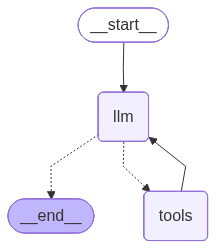

In [13]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, MessagesState, START, END


tool_node = ToolNode(tools, handle_tool_errors=True)

def call_model(state: MessagesState):
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

agent = StateGraph(MessagesState)

agent.add_node("llm", call_model)
agent.add_node("tools", tool_node)
agent.add_edge(START, "llm")
agent.add_conditional_edges("llm", tools_condition)
agent.add_edge("tools", "llm")
agent.add_edge("llm", END)

app = agent.compile()
# Show workflow
display(Image(app.get_graph().draw_mermaid_png()))

In [14]:
# Invoke
from langchain.messages import HumanMessage
messages = [HumanMessage(content="sf 天气如何？再查下最近的网络热点新闻")]
messages = app.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

sf 天气如何？再查下最近的网络热点新闻
================================== Ai Message ==================================
Tool Calls:
  weather_search (call_4d20333fc69a475aa53835)
 Call ID: call_4d20333fc69a475aa53835
  Args:
    query: sf 天气
  web_search (call_2cbcc3338f154bb1b0fd33)
 Call ID: call_2cbcc3338f154bb1b0fd33
  Args:
    query: 最近的网络热点新闻
================================= Tool Message =================================
Name: weather_search

It's 60 degrees and foggy.
================================= Tool Message =================================
Name: web_search

I found this in my browser: 最近的网络热点新闻
================================== Ai Message ==================================

旧金山目前的天气是60度且有雾。

关于最近的网络热点新闻，我需要进一步查找具体信息，请稍等。
